# Under-fitting and Over-fitting

In this lab, we will illustrate the phenomenon of under-fitting and over-fitting using a regression problem. We'll generate a dataset based on a quadratic function and observe how models of varying complexity perform.

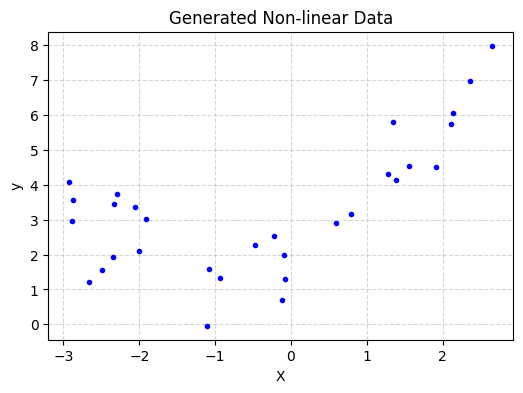

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(11)

# Generate 30 data points
m = 30
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

# Plot the generated data points
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Non-linear Data")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Now, we will fit three Polynomial Regression models to our data to observe different fitting behaviors:
1. A simple Linear Regression model (Degree 1)
2. A Quadratic Regression model (Degree 2)
3. A high-degree Polynomial Regression model (Degree 18)

In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

models = {
    "Model 1": Pipeline([
        ('poly', PolynomialFeatures(degree=1)),
        ('regressor', LinearRegression())
    ]),
    "Model 2": Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('regressor', LinearRegression())
    ]),
    "Model 3": Pipeline([
        ('poly', PolynomialFeatures(degree=15)),
        ('regressor', LinearRegression())
    ])
}

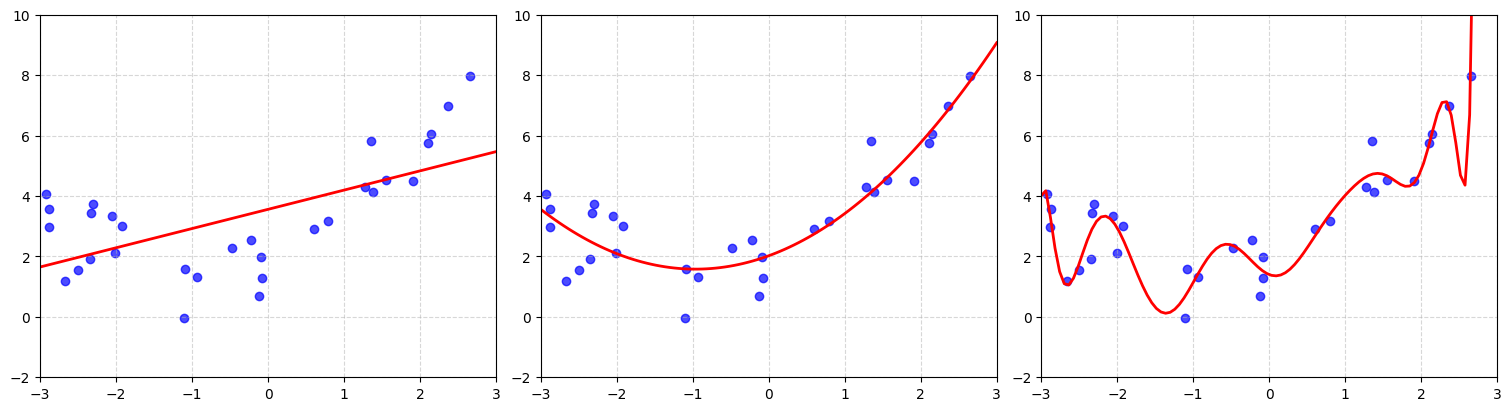

In [3]:
X_plot = np.linspace(-3, 3, 100).reshape(100, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    # Fit the model
    model.fit(X, y)
    
    # Generate predictions for plotting the regression curve
    y_plot = model.predict(X_plot)
    
    # Plot original data points and the regression curve
    axes[i].scatter(X, y, color='blue', alpha=0.7)
    axes[i].plot(X_plot, y_plot, color='red', linewidth=2)
    axes[i].set_xlim(-3, 3)
    axes[i].set_ylim(-2, 10)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.show()

### Observation

- **Under-fitting**: The model is a straight line and is too simple to capture the underlying quadratic pattern of the data.
- **Good Fit**: The model matches the true quadratic nature of our data, resulting in a smooth curve that represents the underlying trend well. 
- **Over-fitting**: The model is overly complex and attempts to pass through or get very close to almost every training point, fitting the random noise rather than the signal. This results in heavy fluctuations and a poorly generalized curve.

Let's quantify our observation such that calculations can select the "good fit" model automatically.

Let's first show what one fold is like:

In [4]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_index, test_index = next(kf.split(X))
X_train, X_test = X[train_index], X[test_index]
y_train, y_test = y[train_index], y[test_index]

Visualization:

- Shows both training and testing data
- Model 1 and 2 are close enough to the testing data
- While Model 3 does well in training data (zero error); since it intersects with all the points in training; the test data shows just how bad the model is.

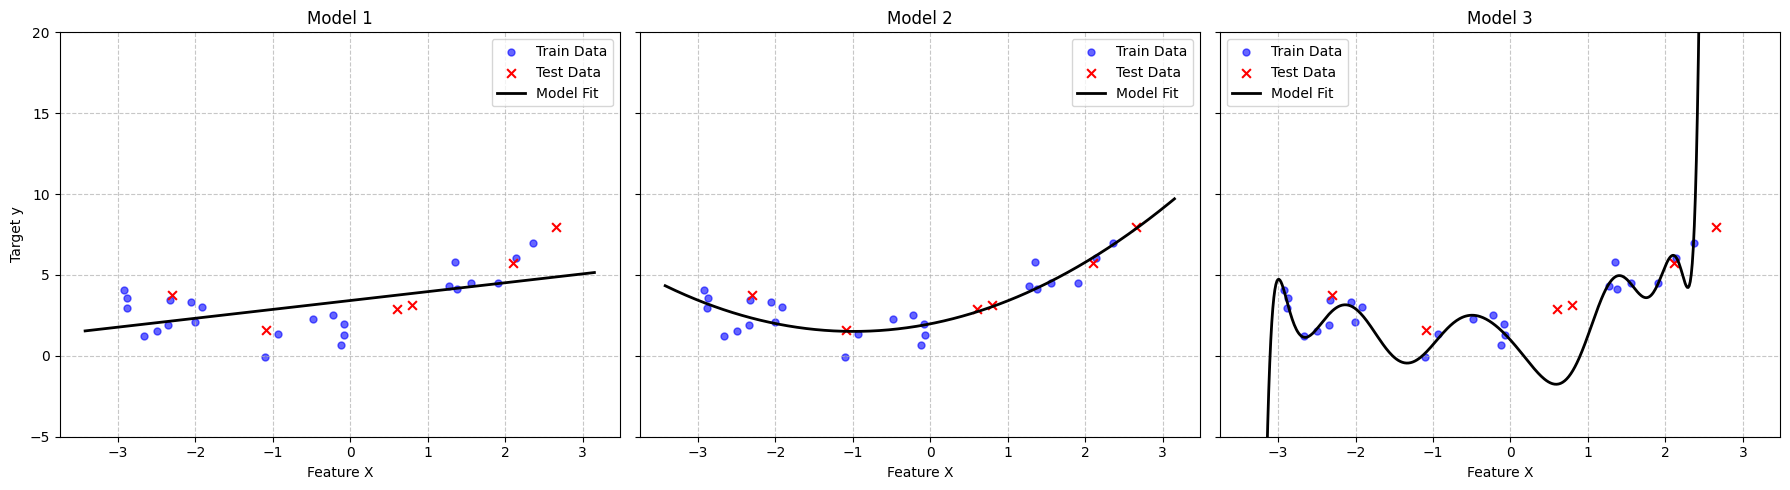

In [5]:
# | code-fold: true

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
x_range = np.linspace(X.min() - 0.5, X.max() + 0.5, 500).reshape(-1, 1)

for ax, (name, model) in zip(axes, models.items()):
    # Fit the model
    model.fit(X_train, y_train)
    y_pred_plot = model.predict(x_range)
    
    # Plot data
    ax.scatter(X_train, y_train, color='blue', alpha=0.6, label='Train Data', s=25)
    ax.scatter(X_test, y_test, color='red', marker='x', label='Test Data', s=40)
    
    # Plot regression curve
    ax.plot(x_range, y_pred_plot, color='black', linewidth=2, label='Model Fit')
    
    ax.set_title(name)
    ax.set_xlabel("Feature X")
    if ax == axes[0]:
        ax.set_ylabel("Target y")
    ax.legend()
    ax.set_ylim(-5, +20)
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Now let's repeat this for 4 more folds:

In [6]:
# Select the 4 remaining folds for the 4x3 visualization
splits = list(kf.split(X))
folds_to_plot = splits[1:]

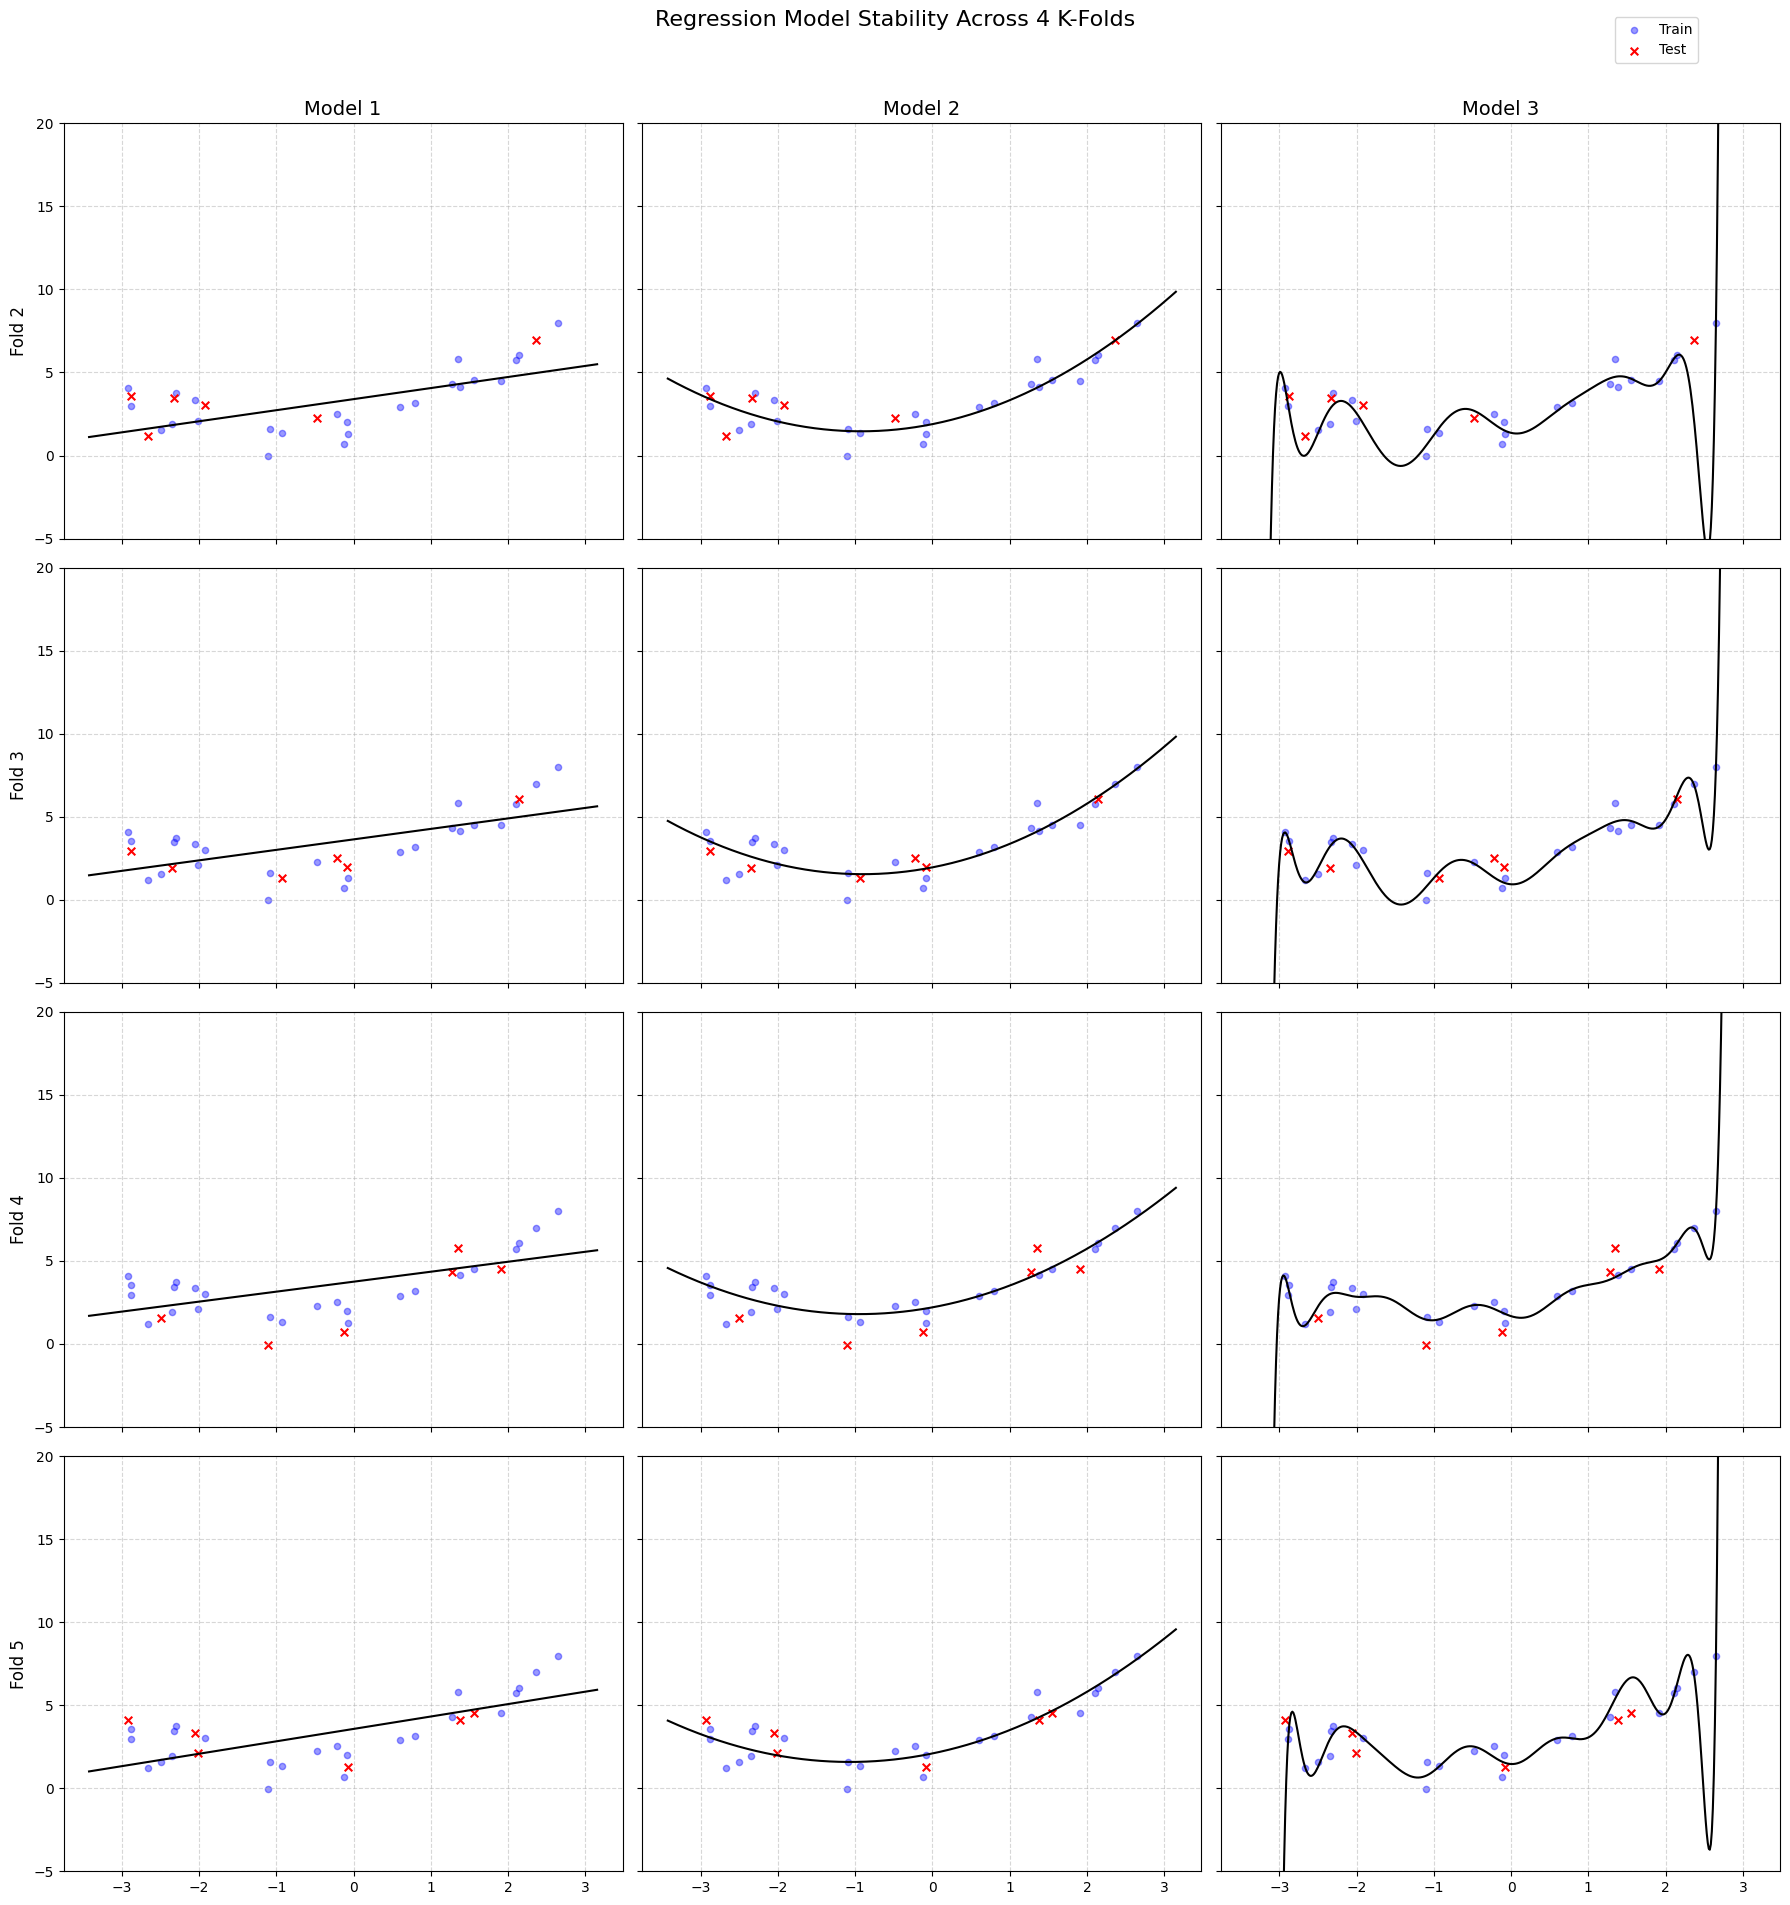

In [7]:
# | code-fold: true

fig, axes = plt.subplots(4, 3, figsize=(18, 20), sharex=True, sharey=True)

for row_idx, (train_index, test_index) in enumerate(folds_to_plot):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    for col_idx, (name, model) in enumerate(models.items()):
        ax = axes[row_idx, col_idx]
        
        # Fit the model on training data for this specific fold
        model.fit(X_train, y_train)
        y_pred_plot = model.predict(x_range)
        
        # Scatter plots for train and test data
        ax.scatter(X_train, y_train, color='blue', alpha=0.4, s=20, label='Train' if row_idx==0 and col_idx==0 else "")
        ax.scatter(X_test, y_test, color='red', marker='x', s=30, label='Test' if row_idx==0 and col_idx==0 else "")
        
        # Regression curve
        ax.plot(x_range, y_pred_plot, color='black', linewidth=1.5)
        
        # Formatting
        if row_idx == 0:
            ax.set_title(name, fontsize=14)
        if col_idx == 0:
            ax.set_ylabel(f"Fold {row_idx + 2}", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_ylim(-5, +20)

fig.suptitle("Regression Model Stability Across 4 K-Folds", fontsize=16)
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.98))
plt.tight_layout(rect=[0, 0.03, 1, 0.96])

Notice how when we train a different Model 1, 2, and 3 on a different sample from the training set, how the curves change shape:

- Models 1 (of Degree 1) have little variation on average
- Models 2 (of Degree 2) have little variation on average
- Models 3 (of Degree 15) have drastic variation on average

## Estimating Generalization Performance with Cross-Validation

While visually inspecting the fitted curves is helpful for 1D data, in real-world problems with many features, we cannot simply rely on visual intuition.

We **Cross-Validation (CV)** which means we will repeatedly re-split our dataset into "train-validation" pairs a number of times, and train the model with a specific **Polynomial Degree**; which we will call by it's proper term: a **Hyper-parameter**.

First we specify the cross-validation strategy: as `KFold`:

In [8]:
from sklearn.model_selection import KFold

k_fold = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

Then, we use the `cross_validate` and pass it the `cv` parameter as the strategy:

In [9]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    models['Model 1'],
    X,
    y,
    cv=k_fold, # Cross-validation Strategy
    scoring="neg_mean_absolute_error"
)

Note: we use the Negative of the MAE (`neg_mean_absolute_error`) because a *Score* in scikit-learn means: higher is better, whereas MAE is an error metric (lower is better). So we invert the sign to indicate just that.

Let's show the results of the cross-validation:

In [10]:
import pandas as pd

df = pd.DataFrame(cv_results)
# invert the sign to get MAE
df['test_score'] = -df['test_score']
df

,fit_time,score_time,test_score
0,0.001114,0.000727,1.200327
1,0.001203,0.000950,2.081100
2,0.001449,0.000690,1.395644
3,0.000982,0.000597,1.268993
4,0.002332,0.000903,0.978988
5,0.000891,0.000544,1.288539
6,0.000871,0.000520,0.699780
7,0.000909,0.000491,2.126412
8,0.000877,0.000518,0.981411
9,0.001978,0.000557,1.419145


Now let's do it for each of the three models, and average the results:

In [ ]:
from sklearn.model_selection import cross_validate
import pandas as pd

# We will store the results in a list and then display them as a DataFrame
cv_results = []

for name, model in models.items():
    # Perform 5-fold cross validation. 
    # Use negative mean absolute error to be consistent with sklearn's scoring optimization.
    scores = cross_validate(
        model,
        X,
        y,
        cv=5, 
        scoring='neg_mean_absolute_error', 
        return_train_score=True
    )
    
    # Calculate the mean of the folds and invert the sign to get MAE
    for s in -scores['train_score']:
        cv_results.append({
        'Model': name,
        'Score': s,
        'Type': 'train'
    })

    for s in -scores['test_score']:
        cv_results.append({
        'Model': name,
        'Score': s,
        'Type': 'test'
    })

### Analyzing the Cross-Validation Results

In [12]:
results_df = pd.DataFrame(cv_results)
results_df.groupby(by=['Model', 'Type']).mean()

Score
Model   Type            
Model 1 test    1.288906
        train   1.212469
Model 2 test    0.731766
        train   0.611688
Model 3 test   27.303262
        train   0.329130

We can also visualize their distribution to see the variance and the discrepency between the training and testing scores, for each one of them:

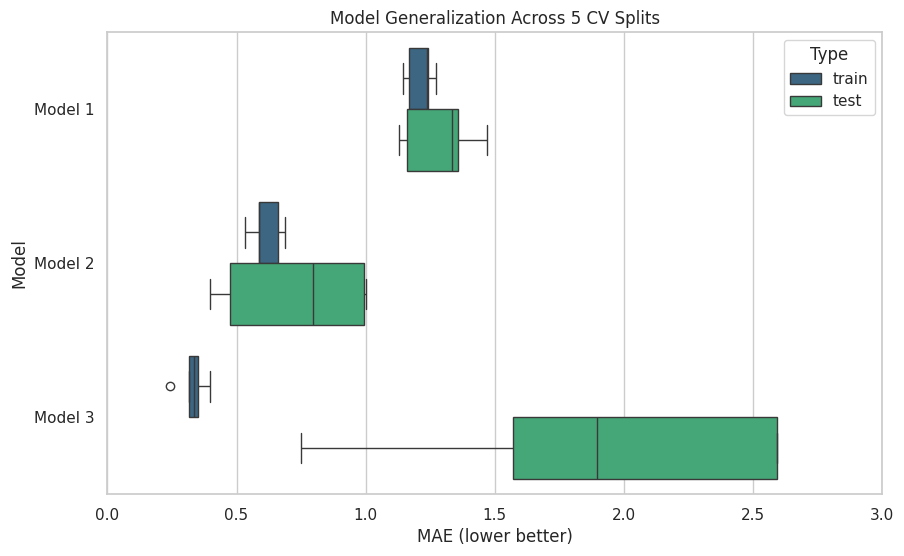

In [13]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    data=results_df, 
    y="Model", 
    x="Score",
    orient='h', 
    hue="Type", 
    palette="viridis",
)

plt.title("Model Generalization Across 5 CV Splits")
plt.xlabel("MAE (lower better)")
plt.ylabel("Model")
plt.xlim(0, 3)
plt.show()

Let's show it using a `barplot` as well:

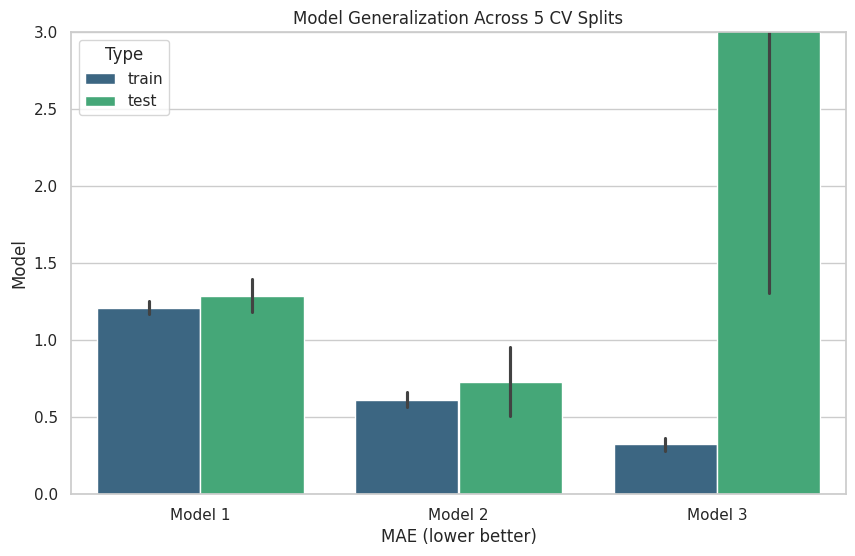

In [14]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=results_df, 
    x="Model",
    y="Score",
    hue="Type", 
    palette="viridis",
)

plt.title("Model Generalization Across 5 CV Splits")
plt.xlabel("MAE (lower better)")
plt.ylabel("Model")
plt.ylim(0, 3)
plt.show()


- **Under-fitting**: Both the Train MAE and Validation MAE are relatively high. The model is too simple (high bias) and cannot fit the data well.
- **Good Fit**: Both Train and Validation MAE are low. The model generalizes well to unseen folds, which agrees with our visual intuition.
- **Over-fitting**: The Train MAE is extremely low (sometimes near zero), but the Validation MAE is very high! The complex model memorized the training patterns (high variance) and fails completely on new, unseen data.

Thus, Cross-Validation provides an automated, numerical approach for verifying the **generalizability** of our model, steering us towards the **Good Fit**.

While we have shown the concept for a regression problem using 1 feature. It:

- applies to classification
- applies to more features


## Validation Curve

[Source: Cross-validation: evaluating estimator performance| Scikit-learn](https://scikit-learn.org/stable/modules/cross_validation.html)

Sometimes it is helpful to plot the influence of a single hyperparameter on the training score and the validation score to find out whether the estimator is overfitting or underfitting for some hyperparameter values.

```python
from sklearn.datasets import load_iris
from sklearn.model_selection import ValidationCurveDisplay
from sklearn.svm import SVC
from sklearn.utils import shuffle

X, y = load_iris(return_X_y=True)
X, y = shuffle(X, y, random_state=0)

ValidationCurveDisplay.from_estimator(
   SVC(kernel="linear"),
   X, y,
   param_name="C",
   param_range=np.logspace(-7, 3, 10)
)
```

![Figure: Validation curve](https://scikit-learn.org/stable/_images/learning_curve-1.png)

- If the training score and the validation score are both low, the estimator will be underfitting.
- If the training score is high and the validation score is low, the estimator is overfitting.
- Otherwise it is working very well (validation score is high).

Note: a low training score and a high validation score is usually not possible. How can one achieve worse on seen examples vs unseen ones?

Source: [3.5.1. Validation curve](https://scikit-learn.org/stable/modules/learning_curve.html#validation-curve).
